In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt

data = [
    {'Student_ID': 'S01', 'Age': 20, 'Gender': 'Male', 'Department': 'CSE', 'Attendance': 85, 'Study_Hours': 3.5, 'CGPA': 3.2},
    {'Student_ID': 'S02', 'Age': 21, 'Gender': 'Female', 'Department': 'EEE', 'Attendance': None, 'Study_Hours': 4.0, 'CGPA': 3.8},
    {'Student_ID': 'S03', 'Age': None, 'Gender': 'Female', 'Department': 'CSE', 'Attendance': 78, 'Study_Hours': 2.5, 'CGPA': 2.9},
    {'Student_ID': 'S04', 'Age': 22, 'Gender': 'Male', 'Department': 'ME', 'Attendance': 90, 'Study_Hours': 3.6, 'CGPA': None},
    {'Student_ID': 'S05', 'Age': 21, 'Gender': 'Female', 'Department': 'EEE', 'Attendance': 65, 'Study_Hours': 1.5, 'CGPA': 2.7},
    {'Student_ID': 'S06', 'Age': 23, 'Gender': 'Female', 'Department': 'CSE', 'Attendance': 88, 'Study_Hours': 4.5, 'CGPA': 3.9},
]

df = pd.DataFrame(data)

In [ ]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Attendance'].fillna(df['Attendance'].mean(), inplace=True)
df['CGPA'].fillna(df['CGPA'].mean(), inplace=True)

print("\nAfter handling missing values:")
print(df)


After handling missing values:
  Student_ID       Age  Gender  Department  Attendance  Study_Hours      CGPA  \
0        S01  0.000000       1           0       0.800     0.666667  0.416667   
1        S02  0.333333       0           1       0.648     0.833333  0.916667   
2        S03  0.466667       0           0       0.520     0.333333  0.166667   
3        S04  0.666667       1           2       1.000     0.700000  0.500000   
4        S05  0.333333       0           1       0.000     0.000000  0.000000   
5        S06  1.000000       0           0       0.920     1.000000  1.000000   

  CGPA_Category  
0        Medium  
1          High  
2           Low  
3        Medium  
4           Low  
5          High  


/tmp/ipykernel_55/3509003885.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_55/3509003885.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
numeric_cols = ['Age', 'Attendance', 'Study_Hours', 'CGPA']
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nAfter normalization:")
print(df)


After normalization:
  Student_ID       Age  Gender Department  Attendance  Study_Hours      CGPA
0        S01  0.000000    Male        CSE       0.800     0.666667  0.416667
1        S02  0.333333  Female        EEE       0.648     0.833333  0.916667
2        S03  0.466667  Female        CSE       0.520     0.333333  0.166667
3        S04  0.666667    Male         ME       1.000     0.700000  0.500000
4        S05  0.333333  Female        EEE       0.000     0.000000  0.000000
5        S06  1.000000  Female        CSE       0.920     1.000000  1.000000


In [ ]:
categorical_cols = ['Gender', 'Department']
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

print("\nAfter Label Encoding:")
print(df)


After Label Encoding:
  Student_ID       Age  Gender  Department  Attendance  Study_Hours      CGPA
0        S01  0.000000       1           0       0.800     0.666667  0.416667
1        S02  0.333333       0           1       0.648     0.833333  0.916667
2        S03  0.466667       0           0       0.520     0.333333  0.166667
3        S04  0.666667       1           2       1.000     0.700000  0.500000
4        S05  0.333333       0           1       0.000     0.000000  0.000000
5        S06  1.000000       0           0       0.920     1.000000  1.000000


In [ ]:
original_cgpa = [3.2, 3.8, 2.9, 3.45, 2.7, 3.9]
df['CGPA_Category'] = pd.cut(
    original_cgpa,
    bins=[-np.inf, 3.0, 3.5, np.inf],
    labels=['Low', 'Medium', 'High']
)

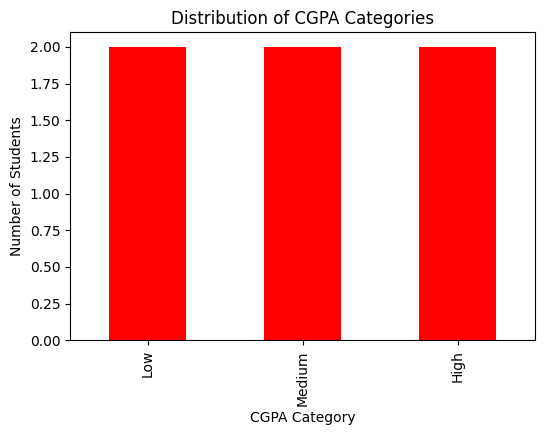


Final DataFrame with CGPA Categories:
  Student_ID       Age  Gender  Department  Attendance  Study_Hours      CGPA  \
0        S01  0.000000       1           0       0.800     0.666667  0.416667   
1        S02  0.333333       0           1       0.648     0.833333  0.916667   
2        S03  0.466667       0           0       0.520     0.333333  0.166667   
3        S04  0.666667       1           2       1.000     0.700000  0.500000   
4        S05  0.333333       0           1       0.000     0.000000  0.000000   
5        S06  1.000000       0           0       0.920     1.000000  1.000000   

  CGPA_Category  
0        Medium  
1          High  
2           Low  
3        Medium  
4           Low  
5          High  


In [ ]:
plt.figure(figsize=(6,4))
df['CGPA_Category'].value_counts().plot(kind='bar', color='Red')
plt.title('Distribution of CGPA Categories')
plt.xlabel('CGPA Category')
plt.ylabel('Number of Students')
plt.show()

print("\nFinal DataFrame with CGPA Categories:")
print(df)